# Run Analysis (PC_1 vs PC_2, kept separate)

This notebook performs run analysis using only the two configured run IDs, with strict separation between machines:
- PC_1: `38658B597A958827`
- PC_2: `043314E3154FFE42`

What it does:
1. Loads `query_timing` (RAPL) and `sigless` (external power) logs.
2. Chunks sigless traces using `start/end` MESSAGE markers for each run.
3. Computes per-run metrics for external and RAPL data.
4. Performs A/B comparisons by query family for each PC separately.
5. Produces A/B plots for Average Power, Total Energy, and Runtime.
6. Runs per-family A/B hypothesis tests and reports which test was used.
7. Runs a cross-PC rank test to check whether family rankings agree between PCs.

In [9]:
import csv
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [3]:
PCS = {
    "PC_1": {
        "run_id": "38658B597A958827",
        "query_timing_file": Path("logs/query_timing_1.csv"),
        "sigless_file": Path("logs/sigless.1774008714209.CH1-0.csv"),
    },
    "PC_2": {
        "run_id": "043314E3154FFE42",
        "query_timing_file": Path("logs/query_timing.csv"),
        "sigless_file": Path("logs/sigless.1774008746572.CH1-0.csv"),
    },
}

for pc_name, cfg in PCS.items():
    print(pc_name, cfg["run_id"])
    print("  query_timing:", cfg["query_timing_file"].resolve())
    print("  sigless:", cfg["sigless_file"].resolve())

PC_1 38658B597A958827
  query_timing: C:\Users\matth\Desktop\Masters-Thesis\logs\query_timing_1.csv
  sigless: C:\Users\matth\Desktop\Masters-Thesis\logs\sigless.1774008714209.CH1-0.csv
PC_2 043314E3154FFE42
  query_timing: C:\Users\matth\Desktop\Masters-Thesis\logs\query_timing.csv
  sigless: C:\Users\matth\Desktop\Masters-Thesis\logs\sigless.1774008746572.CH1-0.csv


In [10]:
import csv
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, spearmanr

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


def parse_message_payload(payload: str) -> dict:
    payload_obj = json.loads(payload)
    message_text = payload_obj.get("message", "")

    fields = {
        "action": None,
        "channelId": payload_obj.get("channelId"),
        "message_timestamp": payload_obj.get("timestamp"),
    }

    parts = [p.strip() for p in message_text.split(",") if p.strip()]
    if parts:
        fields["action"] = parts[0].lower()

    for token in parts[1:]:
        if "=" in token:
            k, v = token.split("=", 1)
            fields[k.strip()] = v.strip()

    return fields


def parse_loop_index(loop_value):
    if loop_value is None or (isinstance(loop_value, float) and np.isnan(loop_value)):
        return np.nan
    text = str(loop_value).strip()
    if "/" in text:
        text = text.split("/", 1)[0]
    try:
        return int(text)
    except ValueError:
        return np.nan


def parse_test_name(test_name: str):
    m = re.match(r"^(?P<family>.+)-query(?P<variant>[AB])\.sql$", str(test_name))
    if not m:
        return None, None
    return m.group("family"), f"QUERY{m.group('variant').upper()}"


def build_external_metrics(sigless_file: Path, run_id_filter: str) -> pd.DataFrame:
    records = []
    active_run = None
    active_power_rows = []

    with sigless_file.open("r", newline="", encoding="utf-8") as handle:
        reader = csv.reader(handle)
        header = next(reader, None)

        for row in reader:
            if len(row) < 4:
                continue

            ts_raw, channel, action, payload = row[0], row[1], row[2].strip(), row[3]
            try:
                timestamp = int(ts_raw)
            except ValueError:
                continue

            if action == "MESSAGE":
                msg = parse_message_payload(payload)
                msg_action = msg.get("action")

                if msg_action == "start":
                    if str(msg.get("run_id", "")) != run_id_filter:
                        continue

                    if active_run is not None:
                        active_run["status"] = "incomplete_missing_end"
                        records.append(active_run)

                    active_run = {
                        "run_id": str(msg.get("run_id")),
                        "test_name": msg.get("test"),
                        "loop_raw": msg.get("loop"),
                        "loop_index": parse_loop_index(msg.get("loop")),
                        "runs": pd.to_numeric(msg.get("runs"), errors="coerce"),
                        "start_ts": timestamp,
                        "status": "open",
                    }
                    active_power_rows = []

                elif msg_action == "end" and active_run is not None:
                    active_run["end_ts"] = timestamp
                    active_run["elapsed_sec_message"] = pd.to_numeric(msg.get("elapsed_sec"), errors="coerce")
                    active_run["failures_message"] = pd.to_numeric(msg.get("failures"), errors="coerce")

                    power_df = pd.DataFrame(active_power_rows)
                    if not power_df.empty:
                        power_df = power_df.sort_values("timestamp").reset_index(drop=True)
                        power_df["time_s"] = (power_df["timestamp"] - power_df["timestamp"].min()) / 1000.0
                        measured_window_sec = float(power_df["time_s"].iloc[-1]) if len(power_df) > 1 else 0.0
                        energy_j = float(np.trapz(power_df["power_w"].to_numpy(), power_df["time_s"].to_numpy())) if len(power_df) > 1 else 0.0
                        avg_power_w = energy_j / measured_window_sec if measured_window_sec > 0 else np.nan

                        active_run["external_samples"] = int(power_df.shape[0])
                        active_run["external_window_sec"] = measured_window_sec
                        active_run["external_energy_j"] = energy_j
                        active_run["external_avg_power_w"] = avg_power_w
                        active_run["external_peak_power_w"] = float(power_df["power_w"].max())
                        active_run["external_min_power_w"] = float(power_df["power_w"].min())
                        active_run["external_std_power_w"] = float(power_df["power_w"].std(ddof=1)) if power_df.shape[0] > 1 else 0.0
                        active_run["status"] = "complete"
                    else:
                        active_run["external_samples"] = 0
                        active_run["external_window_sec"] = np.nan
                        active_run["external_energy_j"] = np.nan
                        active_run["external_avg_power_w"] = np.nan
                        active_run["external_peak_power_w"] = np.nan
                        active_run["external_min_power_w"] = np.nan
                        active_run["external_std_power_w"] = np.nan
                        active_run["status"] = "complete_no_power_rows"

                    records.append(active_run)
                    active_run = None
                    active_power_rows = []

            elif action.startswith("POWER") and active_run is not None:
                try:
                    power_val = float(payload)
                except ValueError:
                    continue

                active_power_rows.append({"timestamp": timestamp, "power_w": power_val})

    if active_run is not None:
        active_run["status"] = "incomplete_missing_end"
        active_run["external_samples"] = len(active_power_rows)
        records.append(active_run)

    ext_df = pd.DataFrame(records)
    if ext_df.empty:
        return ext_df

    ext_df["message_duration_sec"] = (ext_df.get("end_ts", np.nan) - ext_df["start_ts"]) / 1000.0
    return ext_df


def build_rapl_metrics(query_timing_file: Path, run_id_filter: str) -> pd.DataFrame:
    qdf = pd.read_csv(query_timing_file)
    qdf = qdf[qdf["run_id"].astype(str) == str(run_id_filter)].copy()

    numeric_cols = ["loop_index", "total_elapsed_sec", "rapl_package_j", "rapl_core_j", "failures", "runs_per_loop", "total_runs"]
    for col in numeric_cols:
        if col in qdf.columns:
            qdf[col] = pd.to_numeric(qdf[col], errors="coerce")

    qdf["rapl_avg_power_w"] = qdf["rapl_package_j"] / qdf["total_elapsed_sec"]
    qdf["loop_index"] = qdf["loop_index"].astype("Int64")

    keep_cols = [
        "run_id",
        "test_name",
        "loop_index",
        "total_elapsed_sec",
        "rapl_package_j",
        "rapl_core_j",
        "rapl_avg_power_w",
        "failures",
        "runs_per_loop",
        "total_runs",
    ]
    keep_cols = [c for c in keep_cols if c in qdf.columns]
    return qdf[keep_cols].copy()

In [11]:
# Override with a robust reader for malformed lines in query_timing CSVs.
def build_rapl_metrics(query_timing_file: Path, run_id_filter: str) -> pd.DataFrame:
    qdf = pd.read_csv(query_timing_file, engine="python", on_bad_lines="skip")
    qdf = qdf[qdf["run_id"].astype(str) == str(run_id_filter)].copy()

    numeric_cols = ["loop_index", "total_elapsed_sec", "rapl_package_j", "rapl_core_j", "failures", "runs_per_loop", "total_runs"]
    for col in numeric_cols:
        if col in qdf.columns:
            qdf[col] = pd.to_numeric(qdf[col], errors="coerce")

    # Remove malformed/unphysical rows before computing average power.
    qdf = qdf.dropna(subset=["test_name", "loop_index", "total_elapsed_sec", "rapl_package_j"])
    qdf = qdf[(qdf["total_elapsed_sec"] > 0) & (qdf["rapl_package_j"] > 0)]
    qdf = qdf[(qdf["total_elapsed_sec"] < 10000) & (qdf["rapl_package_j"] < 1_000_000)]

    qdf["rapl_avg_power_w"] = qdf["rapl_package_j"] / qdf["total_elapsed_sec"]
    qdf["loop_index"] = qdf["loop_index"].astype("Int64")

    keep_cols = [
        "run_id",
        "test_name",
        "loop_index",
        "total_elapsed_sec",
        "rapl_package_j",
        "rapl_core_j",
        "rapl_avg_power_w",
        "failures",
        "runs_per_loop",
        "total_runs",
    ]
    keep_cols = [c for c in keep_cols if c in qdf.columns]
    return qdf[keep_cols].copy()

In [12]:
# Allow very large MESSAGE payload fields in sigless CSV.
csv.field_size_limit(10_000_000)

10000000

In [13]:
per_pc = {}
merged_frames = []

for pc_name, cfg in PCS.items():
    ext_df = build_external_metrics(cfg["sigless_file"], cfg["run_id"] )
    rapl_df = build_rapl_metrics(cfg["query_timing_file"], cfg["run_id"] )

    if not ext_df.empty:
        ext_df["loop_index"] = pd.to_numeric(ext_df["loop_index"], errors="coerce").astype("Int64")

    merged = rapl_df.merge(
        ext_df,
        on=["run_id", "test_name", "loop_index"],
        how="left",
        suffixes=("", "_sigless"),
    )

    parsed = merged["test_name"].astype(str).apply(parse_test_name)
    merged["query_family"] = [p[0] for p in parsed]
    merged["variant"] = [p[1] for p in parsed]
    merged["pc"] = pc_name

    per_pc[pc_name] = {
        "rapl": rapl_df,
        "external": ext_df,
        "merged": merged,
    }
    merged_frames.append(merged)

    print(f"{pc_name} | run_id={cfg['run_id']}")
    print(f"  RAPL rows: {len(rapl_df)}")
    print(f"  Sigless run records: {len(ext_df)}")
    print(f"  Merge rows: {len(merged)}")
    print(f"  Rows with external avg power: {merged['external_avg_power_w'].notna().sum() if 'external_avg_power_w' in merged.columns else 0}")

analysis_df = pd.concat(merged_frames, ignore_index=True) if merged_frames else pd.DataFrame()

if analysis_df.empty:
    raise ValueError("No data loaded for analysis.")

display(
    analysis_df[[
        "pc", "run_id", "test_name", "loop_index", "query_family", "variant",
        "total_elapsed_sec", "rapl_package_j", "rapl_avg_power_w",
        "external_energy_j", "external_avg_power_w"
    ]].head(12)
 )

PC_1 | run_id=38658B597A958827
  RAPL rows: 767
  Sigless run records: 770
  Merge rows: 767
  Rows with external avg power: 767
PC_2 | run_id=043314E3154FFE42
  RAPL rows: 767
  Sigless run records: 770
  Merge rows: 767
  Rows with external avg power: 767


,pc,run_id,test_name,loop_index,query_family,variant,total_elapsed_sec,rapl_package_j,rapl_avg_power_w,external_energy_j,external_avg_power_w
0,PC_1,38658B597A958827,APX1090-queryA.sql,1,APX1090,QUERYA,115.177635,839.635925,7.289922,1459.226715,12.668768
1,PC_1,38658B597A958827,APX1090-queryA.sql,2,APX1090,QUERYA,114.780950,840.803833,7.325291,1451.745775,12.647852
2,PC_1,38658B597A958827,APX1090-queryA.sql,3,APX1090,QUERYA,114.767936,841.042542,7.328201,1456.144445,12.687943
3,PC_1,38658B597A958827,APX1090-queryA.sql,4,APX1090,QUERYA,114.757765,840.206726,7.321568,1456.377630,12.690528
4,PC_1,38658B597A958827,APX1090-queryA.sql,5,APX1090,QUERYA,114.781595,839.808899,7.316582,1448.455960,12.618861
5,PC_1,38658B597A958827,APX1090-queryA.sql,6,APX1090,QUERYA,114.843412,838.242615,7.299005,1455.692245,12.675388
6,PC_1,38658B597A958827,APX1090-queryA.sql,7,APX1090,QUERYA,114.770456,839.048096,7.310663,1455.950000,12.685585
7,PC_1,38658B597A958827,APX1090-queryA.sql,8,APX1090,QUERYA,114.801069,838.583984,7.304671,1452.669265,12.653252
8,PC_1,38658B597A958827,APX1090-queryA.sql,9,APX1090,QUERYA,114.810410,837.264343,7.292582,1465.107490,12.760037
9,PC_1,38658B597A958827,APX1090-queryA.sql,10,APX1090,QUERYA,114.802003,839.361267,7.311382,1463.132630,12.743837


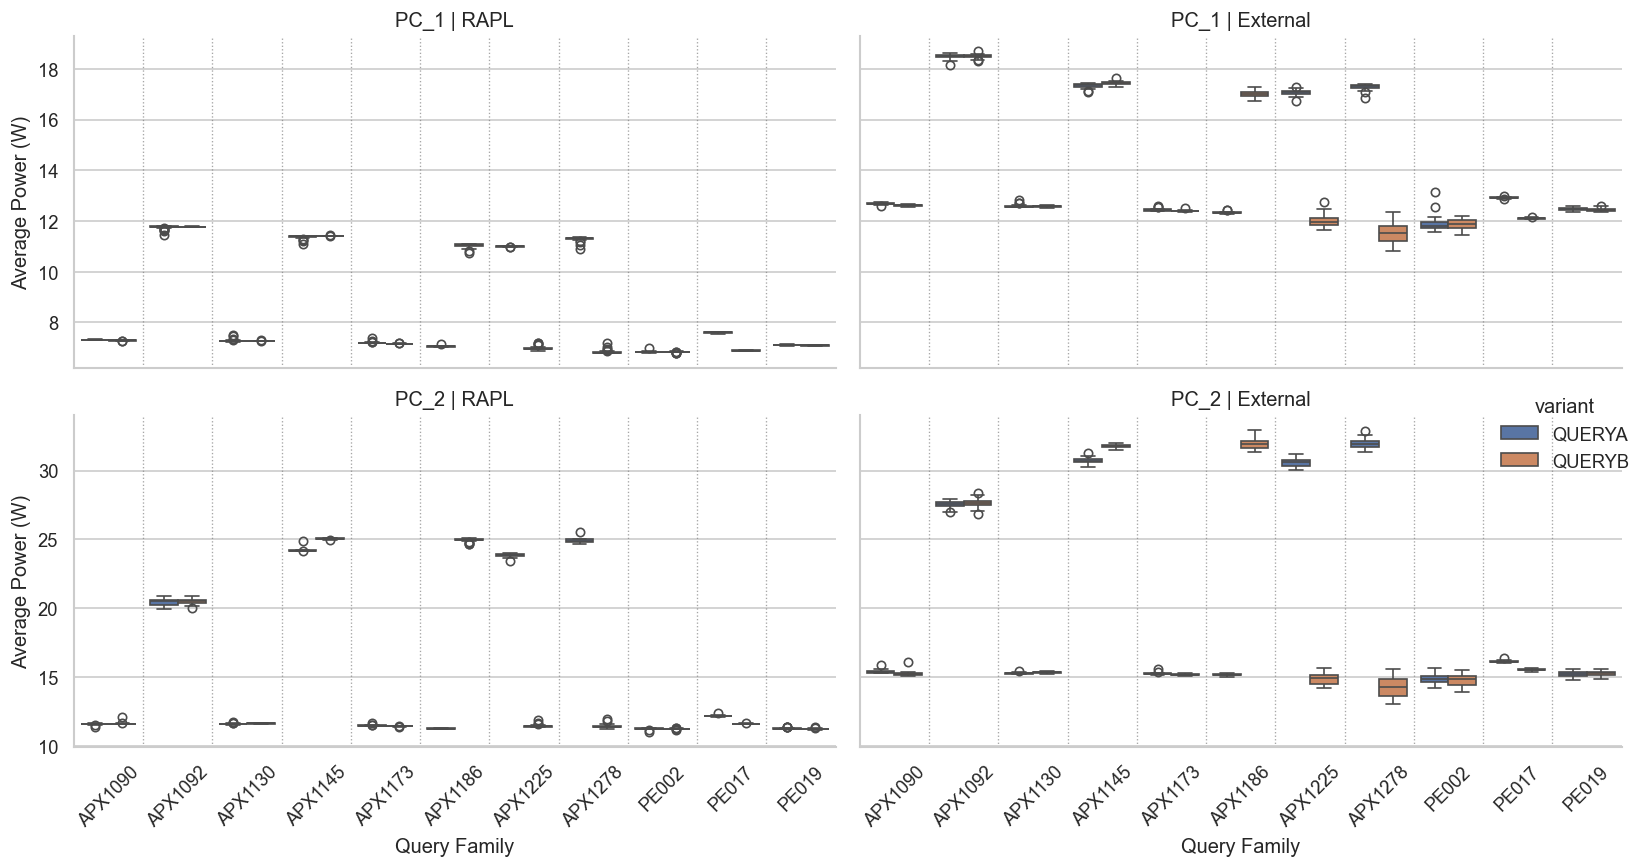

In [22]:
plot_df = analysis_df[analysis_df["variant"].isin(["QUERYA", "QUERYB"])].copy()
query_order = [q for q in pd.unique(plot_df["query_family"].dropna())]

def add_query_dividers(grid_or_axes, n_queries: int):
    if hasattr(grid_or_axes, "axes") and grid_or_axes.axes is not None:
        axes = np.array(grid_or_axes.axes).ravel()
    elif isinstance(grid_or_axes, (list, tuple, np.ndarray)):
        axes = np.array(grid_or_axes).ravel()
    else:
        axes = np.array([grid_or_axes])

    for ax in axes:
        if ax is None:
            continue
        for i in range(n_queries - 1):
            ax.axvline(i + 0.5, linestyle=":", color="gray", linewidth=0.8, alpha=0.7)

# Average Power plot: A/B side-by-side with both RAPL and External shown.
avg_long = plot_df.melt(
    id_vars=["pc", "query_family", "variant"],
    value_vars=["rapl_avg_power_w", "external_avg_power_w"],
    var_name="source_metric",
    value_name="avg_power_w",
)
avg_long["source"] = avg_long["source_metric"].map({
    "rapl_avg_power_w": "RAPL",
    "external_avg_power_w": "External",
})
avg_long = avg_long.dropna(subset=["avg_power_w", "query_family", "variant", "source"] )

if avg_long.empty:
    print("No data available for average-power plotting.")
else:
    g = sns.catplot(
        data=avg_long,
        x="query_family",
        y="avg_power_w",
        hue="variant",
        row="pc",
        col="source",
        row_order=["PC_1", "PC_2"],
        col_order=["RAPL", "External"],
        order=query_order,
        kind="box",
        height=3.7,
        aspect=1.7,
        sharey="row",
    )
    g.set_axis_labels("Query Family", "Average Power (W)")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    plt.show()

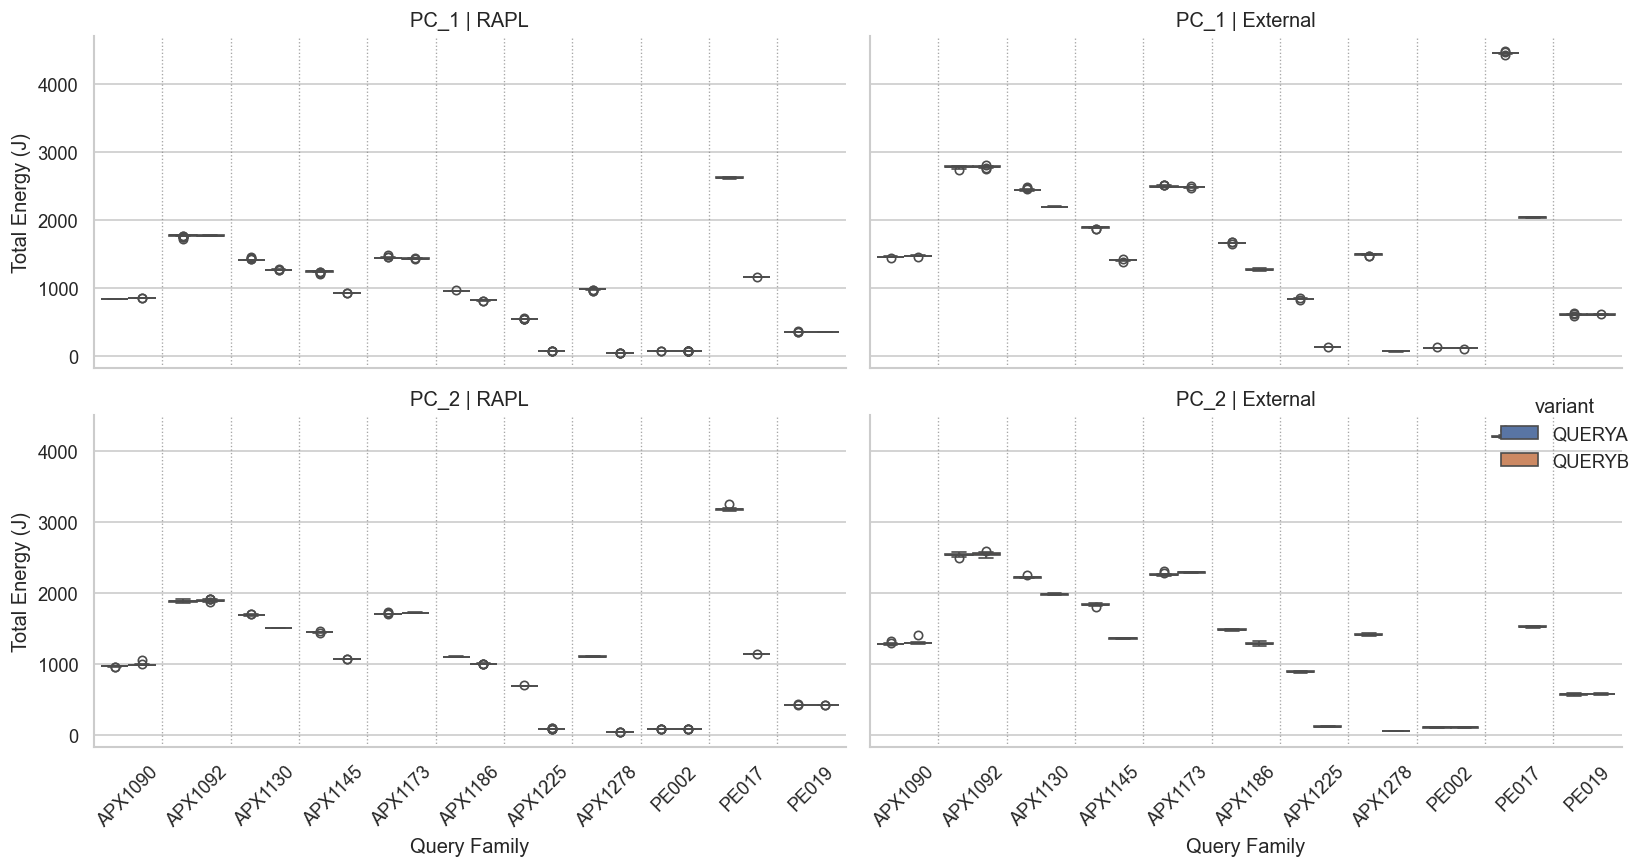

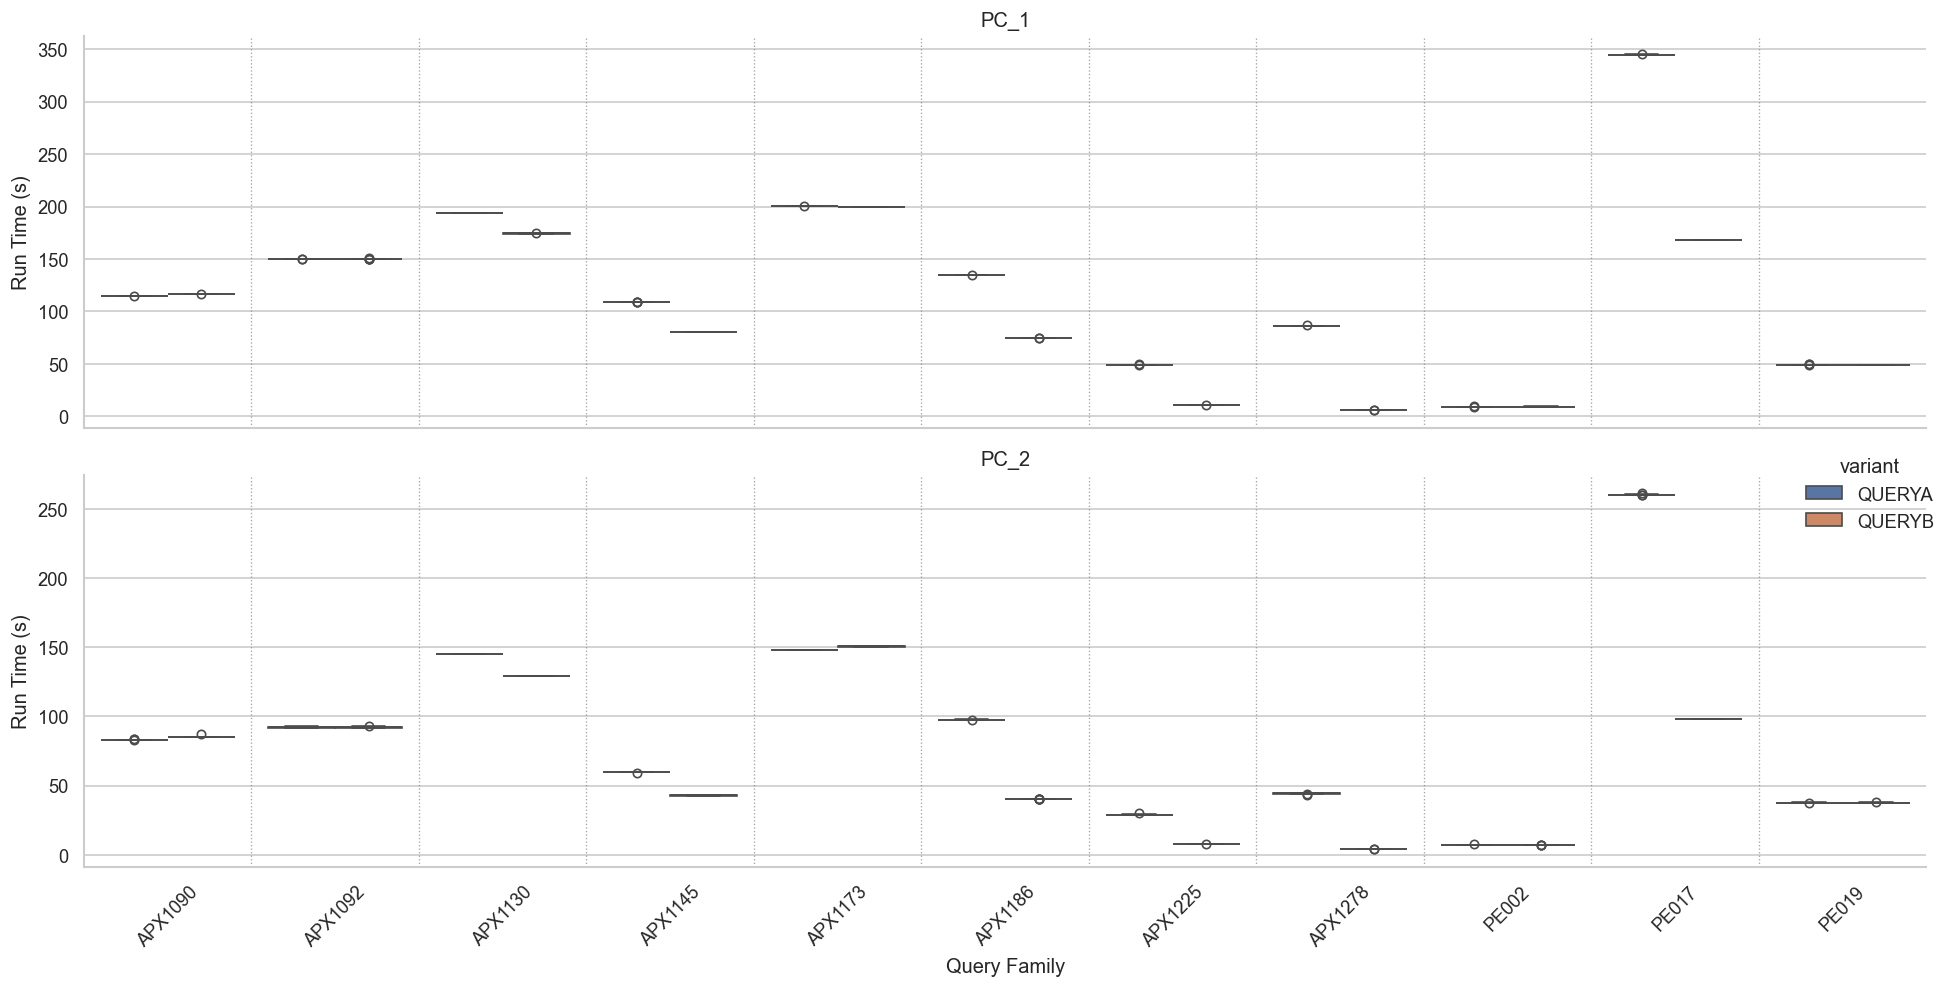

In [23]:
# Total Energy plot: A/B side-by-side with both RAPL and External shown.
energy_long = plot_df.melt(
    id_vars=["pc", "query_family", "variant"],
    value_vars=["rapl_package_j", "external_energy_j"],
    var_name="source_metric",
    value_name="energy_j",
)
energy_long["source"] = energy_long["source_metric"].map({
    "rapl_package_j": "RAPL",
    "external_energy_j": "External",
})
energy_long = energy_long.dropna(subset=["energy_j", "query_family", "variant", "source"] )

if energy_long.empty:
    print("No data available for energy plotting.")
else:
    g = sns.catplot(
        data=energy_long,
        x="query_family",
        y="energy_j",
        hue="variant",
        row="pc",
        col="source",
        row_order=["PC_1", "PC_2"],
        col_order=["RAPL", "External"],
        order=query_order,
        kind="box",
        height=3.7,
        aspect=1.7,
        sharey="row",
    )
    g.set_axis_labels("Query Family", "Total Energy (J)")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    plt.show()

# Runtime plot: A/B side-by-side per query family and PC.
runtime_df = plot_df.dropna(subset=["total_elapsed_sec", "query_family", "variant"] )

if runtime_df.empty:
    print("No data available for runtime plotting.")
else:
    g = sns.catplot(
        data=runtime_df,
        x="query_family",
        y="total_elapsed_sec",
        hue="variant",
        row="pc",
        row_order=["PC_1", "PC_2"],
        order=query_order,
        kind="box",
        height=4.2,
        aspect=3.6,
        sharey=False,
    )
    g.set_axis_labels("Query Family", "Run Time (s)")
    g.set_titles(row_template="{row_name}")
    for ax in g.axes.flat:
        ax.tick_params(axis="x", rotation=45)
    add_query_dividers(g, len(query_order))
    plt.tight_layout()
    plt.show()

In [15]:
def ab_test_by_family(df: pd.DataFrame, value_col: str, metric_label: str, pc_name: str) -> list:
    rows = []
    fam_df = df[df["variant"].isin(["QUERYA", "QUERYB"]) & df["query_family"].notna()].copy()

    for family, g in fam_df.groupby("query_family"):
        a = g.loc[g["variant"] == "QUERYA", value_col].dropna().to_numpy()
        b = g.loc[g["variant"] == "QUERYB", value_col].dropna().to_numpy()

        n_a, n_b = len(a), len(b)
        if n_a < 2 or n_b < 2:
            continue

        shapiro_p_a = shapiro(a).pvalue if n_a >= 3 else np.nan
        shapiro_p_b = shapiro(b).pvalue if n_b >= 3 else np.nan
        normal_a = bool(shapiro_p_a > 0.05) if n_a >= 3 else False
        normal_b = bool(shapiro_p_b > 0.05) if n_b >= 3 else False

        if normal_a and normal_b:
            test_used = "welch_ttest"
            p_value = ttest_ind(a, b, equal_var=False).pvalue
            effect = (np.mean(a) - np.mean(b)) / np.sqrt(((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)) if n_a > 1 and n_b > 1 else np.nan
            effect_label = "std_mean_diff_A_minus_B"
        else:
            test_used = "mannwhitney_u"
            u = mannwhitneyu(a, b, alternative="two-sided").statistic
            p_value = mannwhitneyu(a, b, alternative="two-sided").pvalue
            effect = (2 * u / (n_a * n_b)) - 1
            effect_label = "rank_biserial_A_minus_B"

        rows.append({
            "pc": pc_name,
            "query_family": family,
            "metric": metric_label,
            "n_A": n_a,
            "n_B": n_b,
            "A_mean": float(np.mean(a)),
            "B_mean": float(np.mean(b)),
            "A_minus_B_mean": float(np.mean(a) - np.mean(b)),
            "A_vs_B_mean_pct": float(100 * (np.mean(a) - np.mean(b)) / np.mean(b)) if np.mean(b) != 0 else np.nan,
            "shapiro_p_A": shapiro_p_a,
            "shapiro_p_B": shapiro_p_b,
            "test_used": test_used,
            "p_value": p_value,
            "significant_0_05": bool(p_value < 0.05),
            "effect_label": effect_label,
            "effect_size": effect,
        })

    return rows


metrics_for_tests = [
    ("rapl_avg_power_w", "avg_power_rapl_w"),
    ("external_avg_power_w", "avg_power_external_w"),
    ("rapl_package_j", "energy_rapl_j"),
    ("external_energy_j", "energy_external_j"),
    ("total_elapsed_sec", "runtime_sec"),
]

stat_rows = []
for pc_name, payload in per_pc.items():
    mdf = payload["merged"]
    for col, label in metrics_for_tests:
        if col in mdf.columns:
            stat_rows.extend(ab_test_by_family(mdf, col, label, pc_name))

stats_df = pd.DataFrame(stat_rows)

if stats_df.empty:
    print("No family-level A/B statistical comparisons could be computed.")
else:
    stats_df = stats_df.sort_values(["pc", "metric", "query_family"]).reset_index(drop=True)
    print("A/B statistical test results by PC and query family:")
    display(
        stats_df[[
            "pc", "query_family", "metric", "n_A", "n_B", "test_used", "p_value",
            "significant_0_05", "A_mean", "B_mean", "A_vs_B_mean_pct", "effect_label", "effect_size"
        ]]
    )

    print("Significant results (p < 0.05):")
    display(
        stats_df.loc[stats_df["significant_0_05"]].sort_values(["pc", "metric", "p_value"])[[
            "pc", "query_family", "metric", "test_used", "p_value",
            "A_mean", "B_mean", "A_vs_B_mean_pct", "effect_label", "effect_size"
        ]]
    )

A/B statistical test results by PC and query family:


,pc,query_family,metric,n_A,n_B,test_used,p_value,significant_0_05,A_mean,B_mean,A_vs_B_mean_pct,effect_label,effect_size
0,PC_1,APX1090,avg_power_external_w,35,35,welch_ttest,1.967881e-11,True,12.693162,12.625626,0.534913,std_mean_diff_A_minus_B,1.962074
1,PC_1,APX1092,avg_power_external_w,35,34,mannwhitney_u,9.282729e-01,False,18.491798,18.507593,-0.085344,rank_biserial_A_minus_B,-0.013445
2,PC_1,APX1130,avg_power_external_w,35,35,mannwhitney_u,4.312888e-01,False,12.586189,12.578264,0.063002,rank_biserial_A_minus_B,-0.110204
3,PC_1,APX1145,avg_power_external_w,35,35,mannwhitney_u,8.634218e-09,True,17.333165,17.439408,-0.609214,rank_biserial_A_minus_B,-0.800816
4,PC_1,APX1173,avg_power_external_w,35,34,mannwhitney_u,1.133202e-06,True,12.445301,12.408589,0.295861,rank_biserial_A_minus_B,0.682353
...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,PC_2,APX1225,runtime_sec,35,35,mannwhitney_u,6.545501e-13,True,29.062341,7.941733,265.944595,rank_biserial_A_minus_B,1.000000
106,PC_2,APX1278,runtime_sec,35,35,mannwhitney_u,6.545501e-13,True,44.279798,4.097096,980.760636,rank_biserial_A_minus_B,1.000000
107,PC_2,PE002,runtime_sec,35,35,mannwhitney_u,5.031592e-01,False,7.197295,7.194774,0.035036,rank_biserial_A_minus_B,-0.093878
108,PC_2,PE017,runtime_sec,34,35,mannwhitney_u,9.648700e-13,True,260.529764,98.064152,165.672785,rank_biserial_A_minus_B,1.000000


Significant results (p < 0.05):


,pc,query_family,metric,test_used,p_value,A_mean,B_mean,A_vs_B_mean_pct,effect_label,effect_size
9,PC_1,PE017,avg_power_external_w,welch_ttest,9.008582e-85,12.917727,12.110456,6.665894,std_mean_diff_A_minus_B,34.135222
6,PC_1,APX1225,avg_power_external_w,welch_ttest,2.619412e-58,17.063767,12.002712,42.165930,std_mean_diff_A_minus_B,26.716542
5,PC_1,APX1186,avg_power_external_w,mannwhitney_u,6.545501e-13,12.331630,17.009239,-27.500403,rank_biserial_A_minus_B,-1.000000
7,PC_1,APX1278,avg_power_external_w,mannwhitney_u,6.545501e-13,17.295699,11.546609,49.790288,rank_biserial_A_minus_B,1.000000
0,PC_1,APX1090,avg_power_external_w,welch_ttest,1.967881e-11,12.693162,12.625626,0.534913,std_mean_diff_A_minus_B,1.962074
...,...,...,...,...,...,...,...,...,...,...
102,PC_2,APX1145,runtime_sec,mannwhitney_u,6.545501e-13,59.765785,42.839042,39.512423,rank_biserial_A_minus_B,1.000000
104,PC_2,APX1186,runtime_sec,mannwhitney_u,6.545501e-13,97.767111,40.245982,142.923905,rank_biserial_A_minus_B,1.000000
105,PC_2,APX1225,runtime_sec,mannwhitney_u,6.545501e-13,29.062341,7.941733,265.944595,rank_biserial_A_minus_B,1.000000
106,PC_2,APX1278,runtime_sec,mannwhitney_u,6.545501e-13,44.279798,4.097096,980.760636,rank_biserial_A_minus_B,1.000000


Cross-PC rank agreement test (Spearman) on family-level A-B deltas:


,metric,n_query_families,spearman_rho,p_value,same_ranking_signal
1,avg_power_external_w,11,0.918182,0.000067,True
0,avg_power_rapl_w,11,0.918182,0.000067,True
3,energy_external_j,11,0.872727,0.000455,True
2,energy_rapl_j,11,0.881818,0.000330,True
4,runtime_sec,11,0.872727,0.000455,True


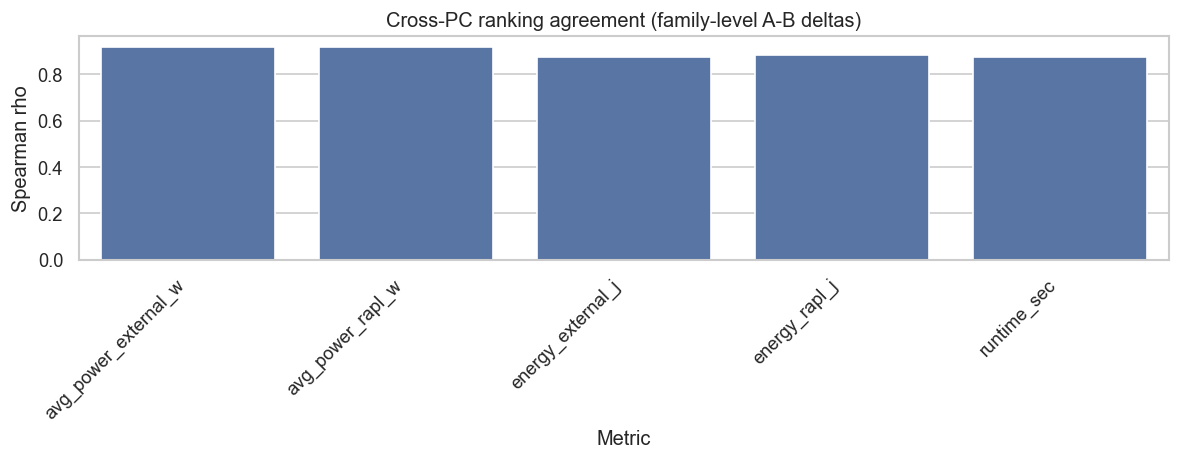

In [16]:
# Cross-PC rank test: compare ranking of family-level A-B effects between PCs.
rank_rows = []

for col, label in metrics_for_tests:
    per_pc_effect = []
    for pc_name, payload in per_pc.items():
        mdf = payload["merged"]
        subset = mdf[mdf["variant"].isin(["QUERYA", "QUERYB"]) & mdf["query_family"].notna()].copy()
        fam = subset.groupby(["query_family", "variant"])[col].median().unstack()
        if "QUERYA" in fam.columns and "QUERYB" in fam.columns:
            fam = fam.dropna(subset=["QUERYA", "QUERYB"]).copy()
            fam["delta_A_minus_B"] = fam["QUERYA"] - fam["QUERYB"]
            fam = fam[["delta_A_minus_B"]].rename(columns={"delta_A_minus_B": pc_name})
            per_pc_effect.append(fam)

    if len(per_pc_effect) < 2:
        continue

    joined = per_pc_effect[0]
    for other in per_pc_effect[1:]:
        joined = joined.join(other, how="inner")

    if {"PC_1", "PC_2"}.issubset(joined.columns) and len(joined) >= 3:
        rho, p = spearmanr(joined["PC_1"], joined["PC_2"])
        rank_rows.append({
            "metric": label,
            "n_query_families": int(len(joined)),
            "spearman_rho": float(rho),
            "p_value": float(p),
            "same_ranking_signal": bool((rho > 0) and (p < 0.05)),
        })

rank_df = pd.DataFrame(rank_rows)

if rank_df.empty:
    print("Not enough overlap to run cross-PC rank tests.")
else:
    print("Cross-PC rank agreement test (Spearman) on family-level A-B deltas:")
    display(rank_df.sort_values("metric"))

    plt.figure(figsize=(10, 4))
    sns.barplot(data=rank_df.sort_values("metric"), x="metric", y="spearman_rho", color="#4C72B0")
    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Spearman rho")
    plt.xlabel("Metric")
    plt.title("Cross-PC ranking agreement (family-level A-B deltas)")
    plt.tight_layout()
    plt.show()

In [17]:
if not stats_df.empty:
    sig_counts = (
        stats_df.groupby(["pc", "metric"], as_index=False)["significant_0_05"]
        .sum()
        .rename(columns={"significant_0_05": "n_significant_families"})
    )
    print("Significant A/B families per PC and metric (p < 0.05):")
    display(sig_counts.sort_values(["pc", "metric"]))

if not rank_df.empty:
    print("Cross-PC rank agreement summary:")
    display(rank_df.sort_values("metric"))

Significant A/B families per PC and metric (p < 0.05):


,pc,metric,n_significant_families
0,PC_1,avg_power_external_w,7
1,PC_1,avg_power_rapl_w,9
2,PC_1,energy_external_j,8
3,PC_1,energy_rapl_j,8
4,PC_1,runtime_sec,9
5,PC_2,avg_power_external_w,8
6,PC_2,avg_power_rapl_w,8
7,PC_2,energy_external_j,9
8,PC_2,energy_rapl_j,9
9,PC_2,runtime_sec,8


Cross-PC rank agreement summary:


,metric,n_query_families,spearman_rho,p_value,same_ranking_signal
1,avg_power_external_w,11,0.918182,0.000067,True
0,avg_power_rapl_w,11,0.918182,0.000067,True
3,energy_external_j,11,0.872727,0.000455,True
2,energy_rapl_j,11,0.881818,0.000330,True
4,runtime_sec,11,0.872727,0.000455,True


In [14]:
# Compute RAPL offset for each test and PC
offset_rows = []

for pc_name, payload in per_pc.items():
    mdf = payload["merged"]
    
    # Group by test_name to get per-test metrics
    for test_name, group in mdf.groupby("test_name"):
        rapl_avg_power = group["rapl_avg_power_w"].median()
        external_avg_power = group["external_avg_power_w"].median()
        
        rapl_energy = group["rapl_package_j"].median()
        external_energy = group["external_energy_j"].median()
        
        # Calculate percentage offsets
        power_offset_pct = (rapl_avg_power - external_avg_power) / external_avg_power * 100 if pd.notna(external_avg_power) and external_avg_power != 0 else np.nan
        energy_offset_pct = (rapl_energy - external_energy) / external_energy * 100 if pd.notna(external_energy) and external_energy != 0 else np.nan
        
        # Parse query family and variant
        family, variant = parse_test_name(test_name)
        
        offset_rows.append({
            "pc": pc_name,
            "test_name": test_name,
            "query_family": family,
            "variant": variant,
            "rapl_avg_power_w": rapl_avg_power if pd.notna(rapl_avg_power) else np.nan,
            "external_avg_power_w": external_avg_power if pd.notna(external_avg_power) else np.nan,
            "power_offset_pct": power_offset_pct,
            "rapl_energy_j": rapl_energy if pd.notna(rapl_energy) else np.nan,
            "external_energy_j": external_energy if pd.notna(external_energy) else np.nan,
            "energy_offset_pct": energy_offset_pct,
            "n_runs": len(group),
        })

offset_df = pd.DataFrame(offset_rows)

if offset_df.empty:
    print("No offset data available.")
else:
    offset_df = offset_df.sort_values(["pc", "query_family", "variant"]).reset_index(drop=True)
    print("RAPL offset (% difference from external measurements) by test and PC:")
    display(offset_df[[
        "pc", "query_family", "variant", "test_name",
        "rapl_avg_power_w", "external_avg_power_w", "power_offset_pct",
        "rapl_energy_j", "external_energy_j", "energy_offset_pct", "n_runs"
    ]])


RAPL offset (% difference from external measurements) by test and PC:


,pc,query_family,variant,test_name,rapl_avg_power_w,external_avg_power_w,power_offset_pct,rapl_energy_j,external_energy_j,energy_offset_pct,n_runs
0,PC_1,APX1090,QUERYA,APX1090-queryA.sql,7.302836,12.690528,-42.454432,838.466919,1457.867915,-42.486771,35
1,PC_1,APX1090,QUERYB,APX1090-queryB.sql,7.290804,12.626516,-42.257996,849.679504,1471.499905,-42.257590,35
2,PC_1,APX1092,QUERYA,APX1092-queryA.sql,11.780478,18.522867,-36.400351,1769.904053,2782.227245,-36.385353,35
3,PC_1,APX1092,QUERYB,APX1092-queryB.sql,11.773909,18.515359,-36.410044,1769.432739,2782.350330,-36.405106,34
4,PC_1,APX1130,QUERYA,APX1130-queryA.sql,7.261987,12.571178,-42.233042,1407.154907,2435.576415,-42.224974,35
5,PC_1,APX1130,QUERYB,APX1130-queryB.sql,7.274757,12.577635,-42.161166,1268.105103,2192.709370,-42.167206,35
6,PC_1,APX1145,QUERYA,APX1145-queryA.sql,11.391039,17.352646,-34.355610,1241.896912,1892.099040,-34.364064,35
7,PC_1,APX1145,QUERYB,APX1145-queryB.sql,11.400618,17.448273,-34.660480,919.202698,1405.963850,-34.621171,35
8,PC_1,APX1173,QUERYA,APX1173-queryA.sql,7.192446,12.430701,-42.139657,1440.714233,2490.204985,-42.144753,35
9,PC_1,APX1173,QUERYB,APX1173-queryB.sql,7.161879,12.408257,-42.281343,1431.080353,2478.781997,-42.266793,34


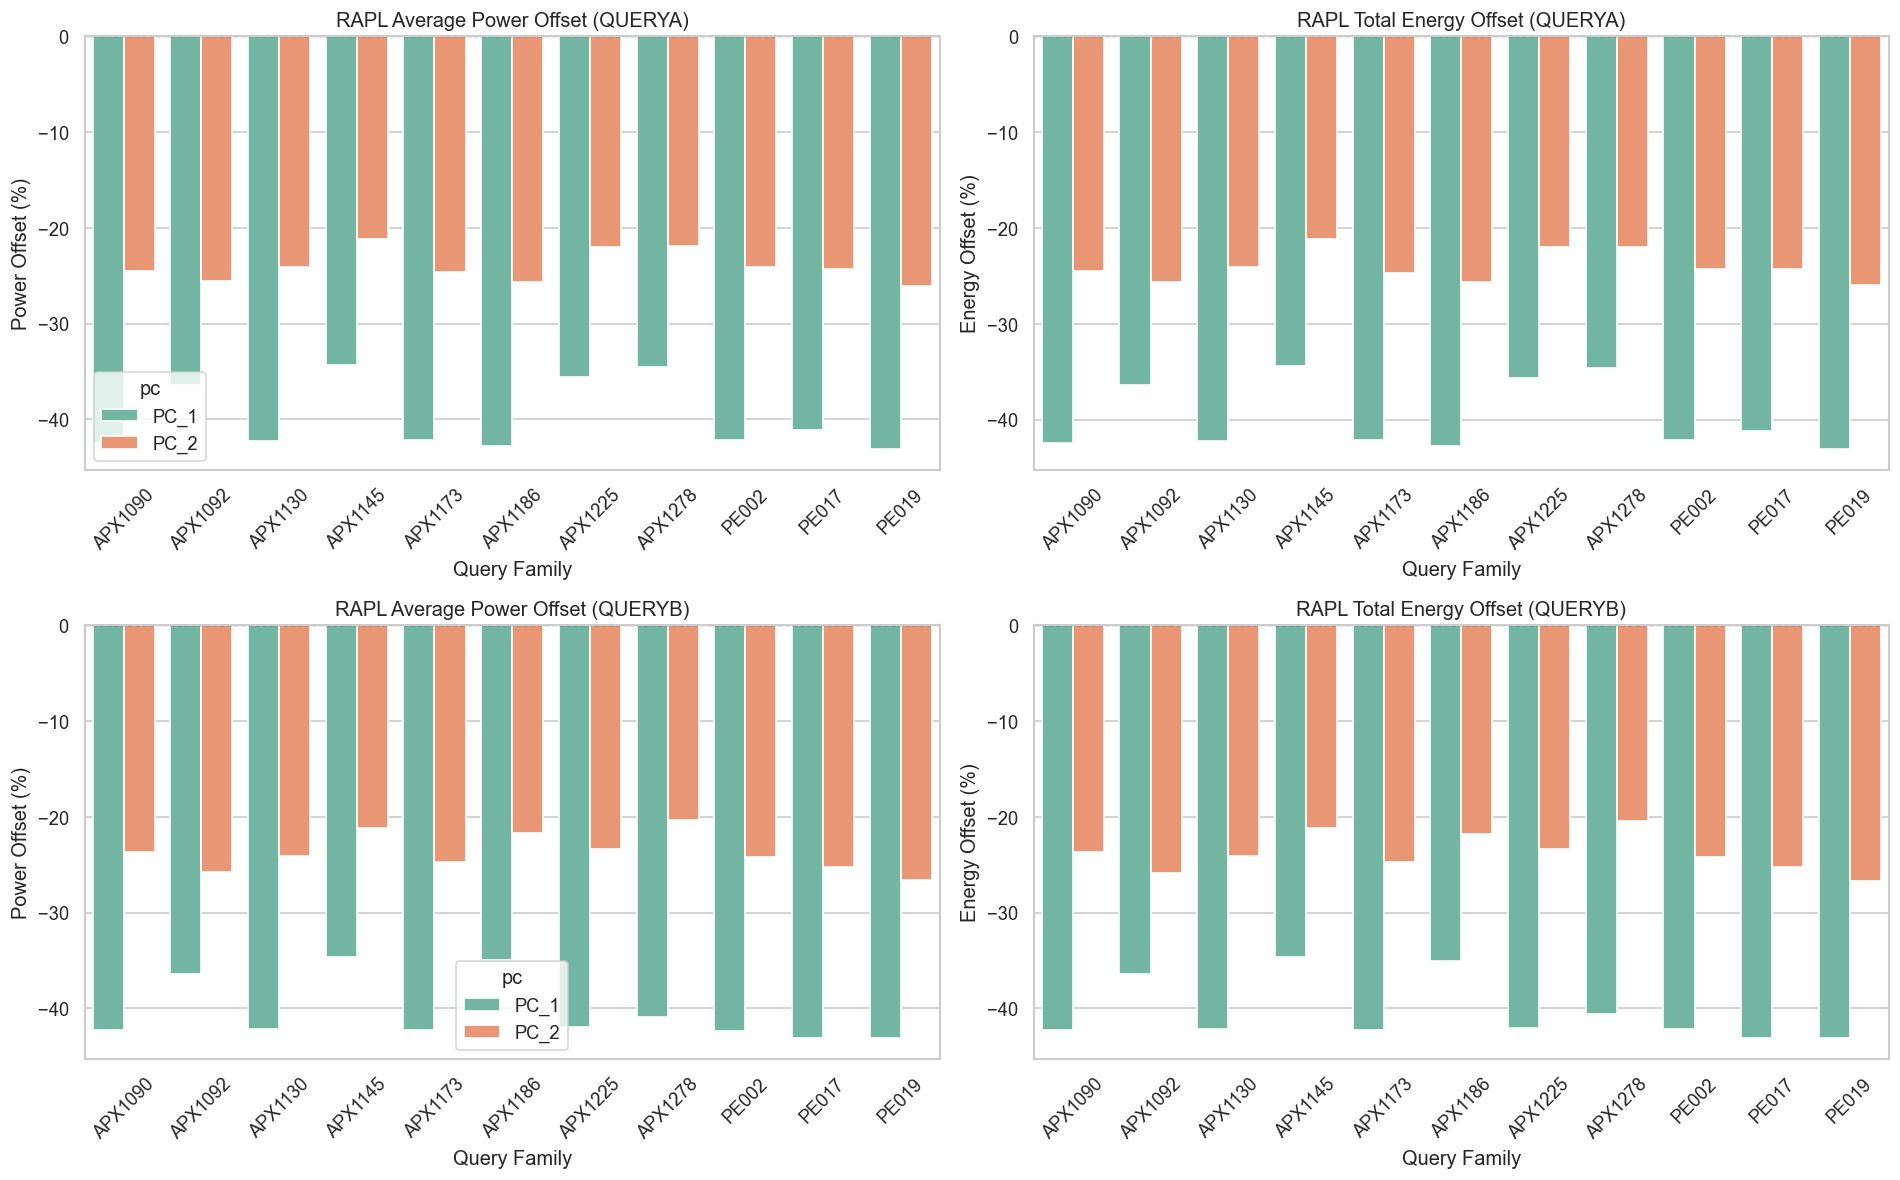


RAP offset summary by PC and variant:


power_offset_pct                                             \
                         mean     median        min        max       std   
variant pc                                                                 
QUERYA  PC_1       -39.719120 -42.095608 -43.091189 -34.355610  3.623918   
        PC_2       -23.992930 -24.276058 -26.032353 -21.154896  1.641244   
QUERYB  PC_1       -40.376171 -42.161166 -43.113571 -34.660480  3.306074   
        PC_2       -23.692002 -24.087413 -26.562462 -20.346078  1.946563   

             energy_offset_pct                                             
                          mean     median        min        max       std  
variant pc                                                                 
QUERYA  PC_1        -39.721248 -42.104315 -43.065224 -34.364064  3.618654  
        PC_2        -24.019042 -24.297478 -25.965394 -21.203567  1.616752  
QUERYB  PC_1        -40.341410 -42.167206 -43.115378 -34.621171  3.299726  
        PC_2        -23.737925 -24.099459 -26.675993 -20.413204  1.962779

In [19]:
# Visualize RAPL offsets by metric and PC, separated by variant (Query A vs B)
if not offset_df.empty:
    plot_offset = offset_df.dropna(subset=["power_offset_pct", "energy_offset_pct"]).copy()
    
    if not plot_offset.empty:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # For each variant, create power and energy offset plots
        for idx, variant in enumerate(["QUERYA", "QUERYB"]):
            variant_data = plot_offset[plot_offset["variant"] == variant].sort_values(["pc", "query_family"])
            
            if variant_data.empty:
                continue
            
            # Power offset plot
            sns.barplot(
                data=variant_data,
                x="query_family", y="power_offset_pct", hue="pc",
                ax=axes[idx, 0], palette="Set2"
            )
            axes[idx, 0].set_title(f"RAPL Average Power Offset ({variant})")
            axes[idx, 0].set_ylabel("Power Offset (%)")
            axes[idx, 0].set_xlabel("Query Family")
            axes[idx, 0].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
            axes[idx, 0].tick_params(axis="x", rotation=45)
            
            # Energy offset plot
            sns.barplot(
                data=variant_data,
                x="query_family", y="energy_offset_pct", hue="pc",
                ax=axes[idx, 1], palette="Set2"
            )
            axes[idx, 1].set_title(f"RAPL Total Energy Offset ({variant})")
            axes[idx, 1].set_ylabel("Energy Offset (%)")
            axes[idx, 1].set_xlabel("Query Family")
            axes[idx, 1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
            axes[idx, 1].tick_params(axis="x", rotation=45)
            axes[idx, 1].get_legend().remove()
        
        plt.tight_layout()
        plt.show()
        
        # Summary statistics
        print("\nRAP offset summary by PC and variant:")
        summary = offset_df.groupby(["variant", "pc"])[["power_offset_pct", "energy_offset_pct"]].agg([
            ("mean", "mean"),
            ("median", "median"),
            ("min", "min"),
            ("max", "max"),
            ("std", "std"),
        ])
        display(summary)


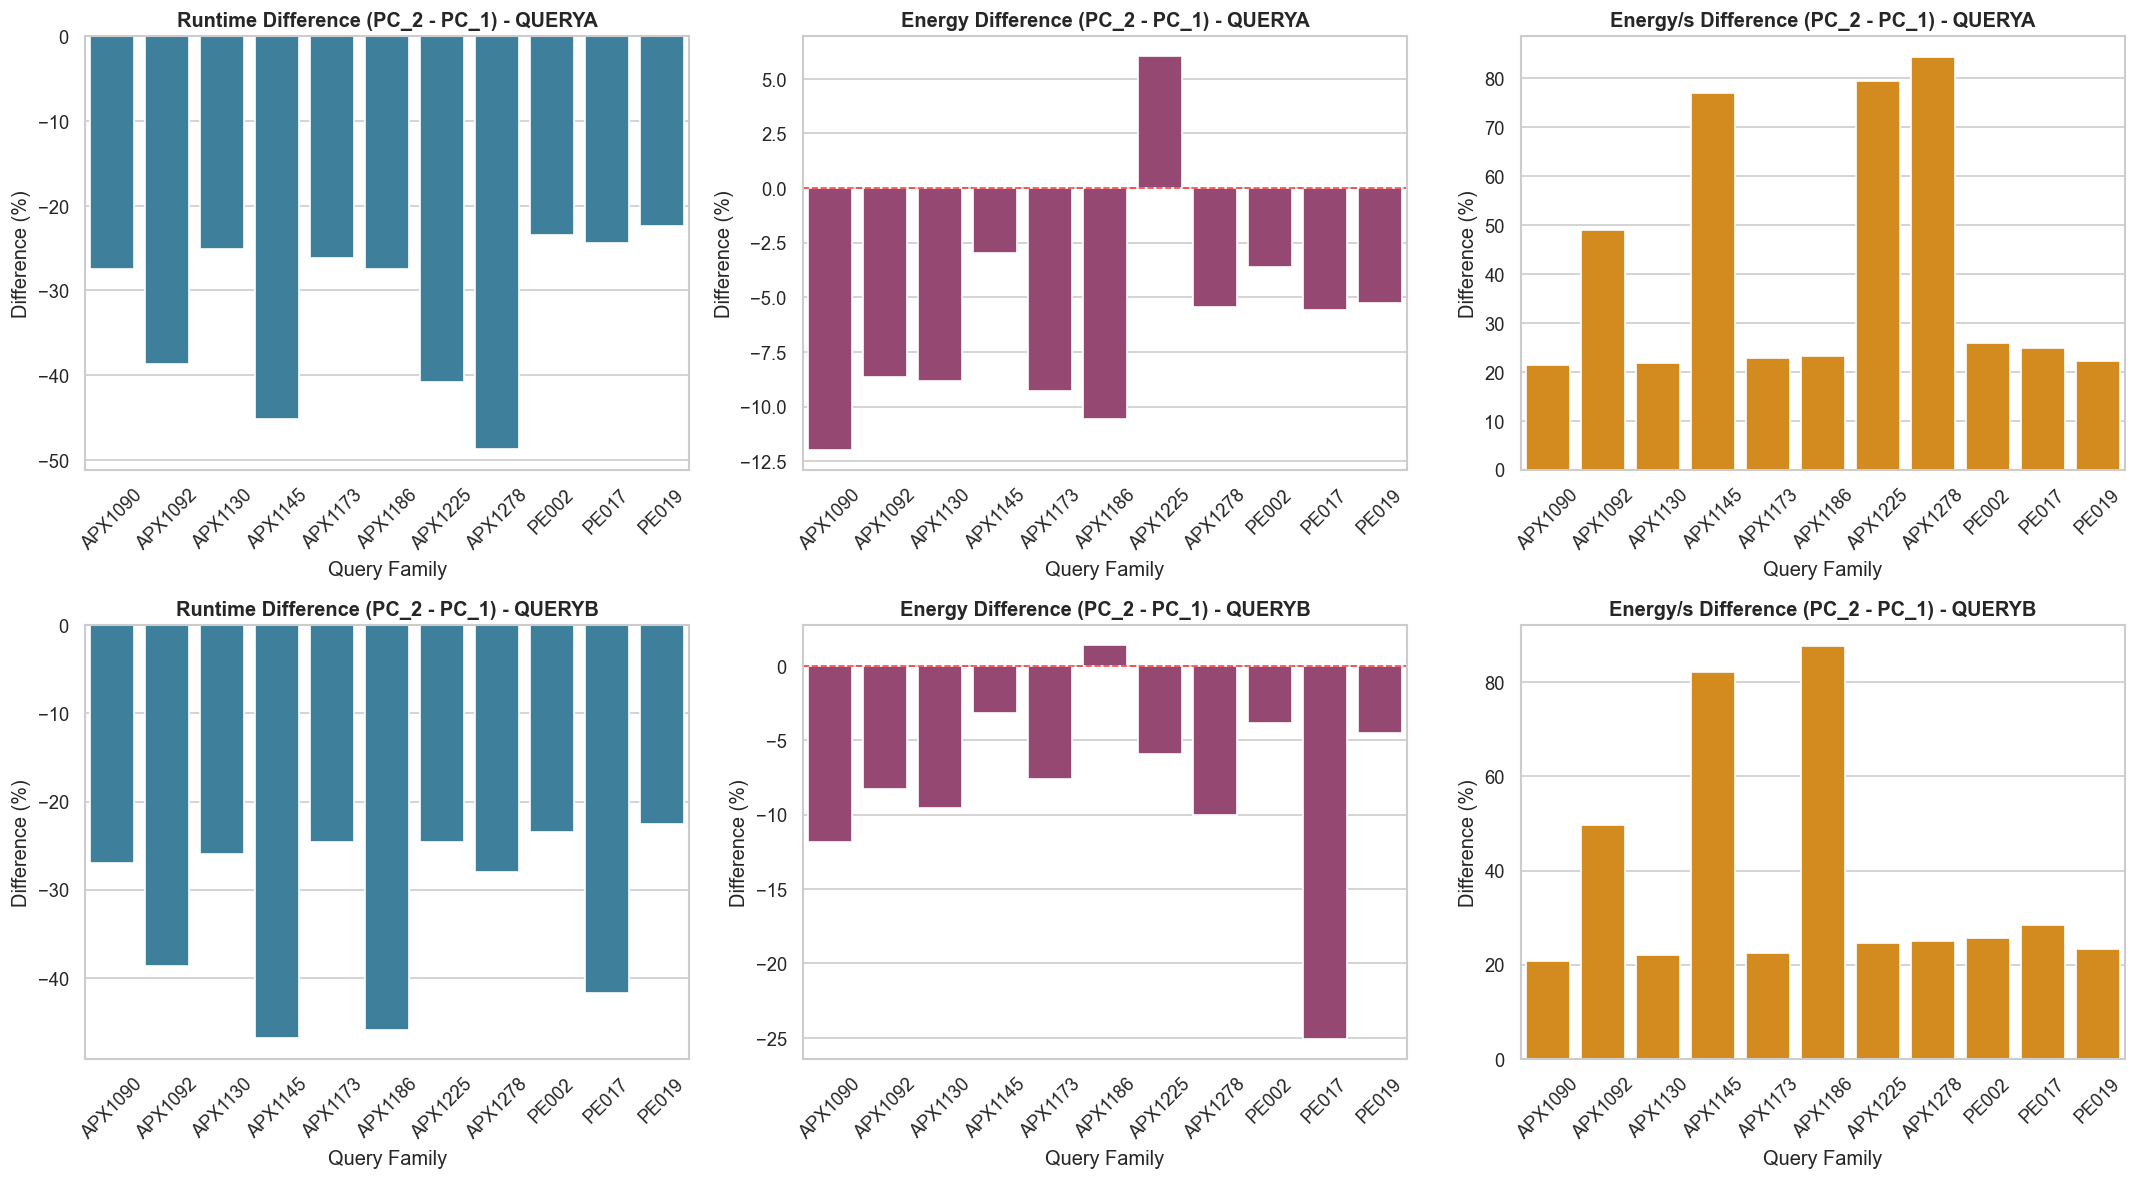

PC_1 vs PC_2 Comparison (median values by test, separated by variant):


,variant,query_family,pc1_runtime_sec,pc2_runtime_sec,runtime_diff_pct,pc1_energy_j,pc2_energy_j,energy_diff_pct,pc1_energy_per_sec,pc2_energy_per_sec,energy_per_sec_diff_pct
0,QUERYA,APX1090,114.798472,83.216858,-27.510483,1457.867915,1283.134960,-11.985513,12.699367,15.419171,21.416848
2,QUERYA,APX1092,150.237515,92.121016,-38.683081,2782.227245,2541.079910,-8.667421,18.518858,27.584150,48.951677
4,QUERYA,APX1130,193.786966,145.058610,-25.145322,2435.576415,2220.627797,-8.825369,12.568319,15.308487,21.802181
6,QUERYA,APX1145,109.042230,59.792459,-45.165778,1892.099040,1835.866630,-2.971959,17.351984,30.703983,76.947965
8,QUERYA,APX1173,200.348819,147.946886,-26.155349,2490.204985,2258.381140,-9.309428,12.429347,15.264810,22.812649
11,QUERYA,APX1186,134.749038,97.770859,-27.442258,1660.678420,1484.814175,-10.589904,12.324232,15.186674,23.226129
12,QUERYA,APX1225,49.107202,29.045525,-40.852820,838.622865,889.304565,6.043444,17.077391,30.617610,79.287405
14,QUERYA,APX1278,86.355752,44.292805,-48.708912,1496.314055,1414.555015,-5.464029,17.327324,31.936451,84.312663
16,QUERYA,PE002,9.393218,7.190568,-23.449365,111.051465,107.047900,-3.605144,11.822515,14.887266,25.923001
18,QUERYA,PE017,344.713912,260.506109,-24.428316,4452.188270,4202.824350,-5.600929,12.915604,16.133304,24.913282


In [20]:
# PC_1 vs PC_2 comparison: Runtime and Energy differences by test
comparison_rows = []

for test_name in analysis_df["test_name"].unique():
    if pd.isna(test_name):
        continue
    
    pc1_data = analysis_df[(analysis_df["pc"] == "PC_1") & (analysis_df["test_name"] == test_name)]
    pc2_data = analysis_df[(analysis_df["pc"] == "PC_2") & (analysis_df["test_name"] == test_name)]
    
    if pc1_data.empty or pc2_data.empty:
        continue
    
    pc1_runtime = pc1_data["total_elapsed_sec"].median()
    pc2_runtime = pc2_data["total_elapsed_sec"].median()
    
    pc1_energy = pc1_data["external_energy_j"].median()
    pc2_energy = pc2_data["external_energy_j"].median()
    
    # Calculate differences and percent differences
    runtime_diff = pc2_runtime - pc1_runtime
    runtime_diff_pct = (runtime_diff / pc1_runtime * 100) if pc1_runtime > 0 else np.nan
    
    energy_diff = pc2_energy - pc1_energy
    energy_diff_pct = (energy_diff / pc1_energy * 100) if pc1_energy > 0 else np.nan
    
    # Calculate energy per second (average power from external measurements)
    pc1_energy_per_sec = pc1_energy / pc1_runtime if pc1_runtime > 0 else np.nan
    pc2_energy_per_sec = pc2_energy / pc2_runtime if pc2_runtime > 0 else np.nan
    
    energy_per_sec_diff = pc2_energy_per_sec - pc1_energy_per_sec
    energy_per_sec_diff_pct = (energy_per_sec_diff / pc1_energy_per_sec * 100) if pd.notna(pc1_energy_per_sec) and pc1_energy_per_sec > 0 else np.nan
    
    # Parse query family
    family, variant = parse_test_name(test_name)
    
    comparison_rows.append({
        "test_name": test_name,
        "query_family": family,
        "variant": variant,
        "pc1_runtime_sec": pc1_runtime,
        "pc2_runtime_sec": pc2_runtime,
        "runtime_diff_sec": runtime_diff,
        "runtime_diff_pct": runtime_diff_pct,
        "pc1_energy_j": pc1_energy,
        "pc2_energy_j": pc2_energy,
        "energy_diff_j": energy_diff,
        "energy_diff_pct": energy_diff_pct,
        "pc1_energy_per_sec": pc1_energy_per_sec,
        "pc2_energy_per_sec": pc2_energy_per_sec,
        "energy_per_sec_diff": energy_per_sec_diff,
        "energy_per_sec_diff_pct": energy_per_sec_diff_pct,
    })

comparison_df = pd.DataFrame(comparison_rows)

if not comparison_df.empty:
    comparison_df = comparison_df.sort_values("query_family").reset_index(drop=True)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Create plots for each variant (QUERYA and QUERYB)
    for var_idx, variant in enumerate(["QUERYA", "QUERYB"]):
        variant_df = comparison_df[comparison_df["variant"] == variant].sort_values("query_family")
        
        if variant_df.empty:
            continue
        
        # Runtime difference plot
        sns.barplot(
            data=variant_df,
            x="query_family",
            y="runtime_diff_pct",
            ax=axes[var_idx, 0],
            color="#2E86AB"
        )
        axes[var_idx, 0].set_title(f"Runtime Difference (PC_2 - PC_1) - {variant}", fontsize=12, fontweight="bold")
        axes[var_idx, 0].set_ylabel("Difference (%)")
        axes[var_idx, 0].set_xlabel("Query Family")
        axes[var_idx, 0].axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.7)
        axes[var_idx, 0].tick_params(axis="x", rotation=45)
        
        # Energy difference plot
        sns.barplot(
            data=variant_df,
            x="query_family",
            y="energy_diff_pct",
            ax=axes[var_idx, 1],
            color="#A23B72"
        )
        axes[var_idx, 1].set_title(f"Energy Difference (PC_2 - PC_1) - {variant}", fontsize=12, fontweight="bold")
        axes[var_idx, 1].set_ylabel("Difference (%)")
        axes[var_idx, 1].set_xlabel("Query Family")
        axes[var_idx, 1].axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.7)
        axes[var_idx, 1].tick_params(axis="x", rotation=45)
        
        # Energy per second difference plot
        sns.barplot(
            data=variant_df,
            x="query_family",
            y="energy_per_sec_diff_pct",
            ax=axes[var_idx, 2],
            color="#F18F01"
        )
        axes[var_idx, 2].set_title(f"Energy/s Difference (PC_2 - PC_1) - {variant}", fontsize=12, fontweight="bold")
        axes[var_idx, 2].set_ylabel("Difference (%)")
        axes[var_idx, 2].set_xlabel("Query Family")
        axes[var_idx, 2].axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.7)
        axes[var_idx, 2].tick_params(axis="x", rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("PC_1 vs PC_2 Comparison (median values by test, separated by variant):")
    display(comparison_df.sort_values(["variant", "query_family"])[[
        "variant", "query_family",
        "pc1_runtime_sec", "pc2_runtime_sec", "runtime_diff_pct",
        "pc1_energy_j", "pc2_energy_j", "energy_diff_pct",
        "pc1_energy_per_sec", "pc2_energy_per_sec", "energy_per_sec_diff_pct"
    ]])
